# Deliverable 1 — Document Extraction Accuracy

Implements proposal **Metric 1 (F1)** and **POC Deliverable 1**: macro F1, critical-field F1, document-type confusion matrix, and the **Document AI vs LLM vs Hybrid** comparison.

Field matching mirrors the repository harness `calculateExtractionAccuracy` (`tests/eval/validators.ts`), extended to be numeric-aware for money/dates.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('/Users/agentilt/github/OneLPMVP/capstone')
sys.path.insert(0, str(ROOT / 'lib'))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('capstone root:', ROOT)


capstone root: /Users/agentilt/github/OneLPMVP/capstone


## 1. Load metrics
Re-run `run_eval.py` first if `results/` is empty.

In [2]:
res = json.load(open(ROOT/'deliverable-1-extraction-accuracy'/'results'/'extraction_metrics.json'))
summary = pd.DataFrame(res['summary']).T[['macro_f1','critical_field_f1','micro_f1','latency_p50','latency_p95']]
summary.index = ['Document AI only','LLM only','Hybrid (merged)']
summary

,macro_f1,critical_field_f1,micro_f1,latency_p50,latency_p95
Document AI only,0.889,0.963,0.846,10.705,14.677
LLM only,0.892,0.887,0.903,28.335,41.295
Hybrid (merged),0.968,0.968,0.965,32.440,45.922


**Hybrid is the only engine clearing both targets** (macro ≥ 0.90, critical ≥ 0.95).

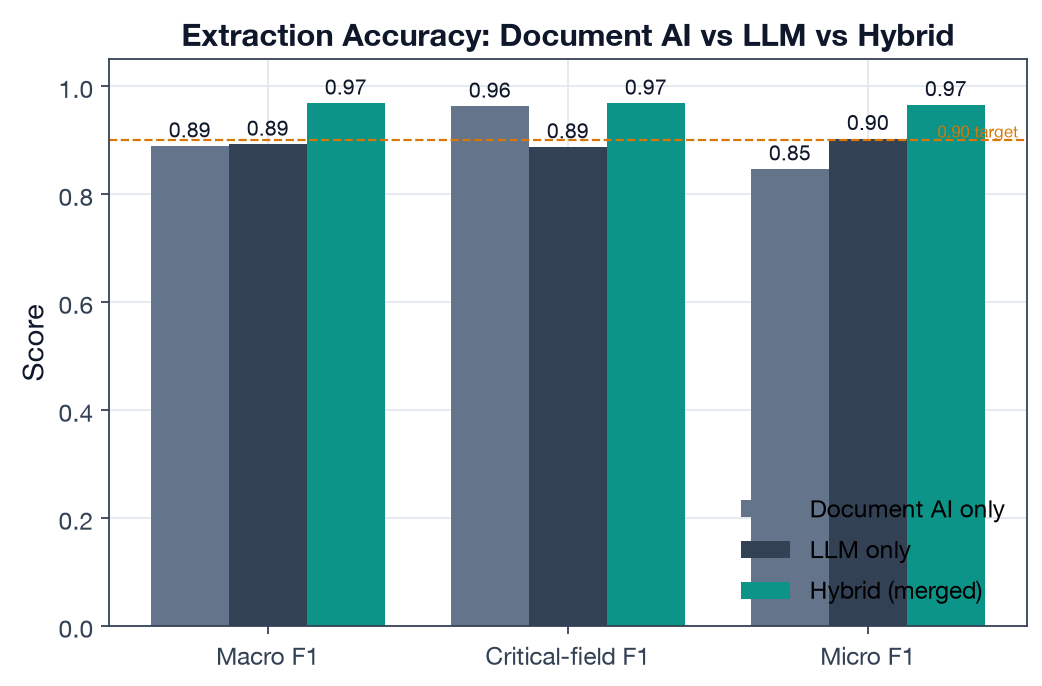

In [3]:
display(Image(str(ROOT/'deliverable-1-extraction-accuracy'/'figures'/'engine_comparison.png')))

## 2. Per-field F1 — the complementary failure modes
Document AI wins on structured/critical fields; the LLM wins on narrative; hybrid takes the better source per field.

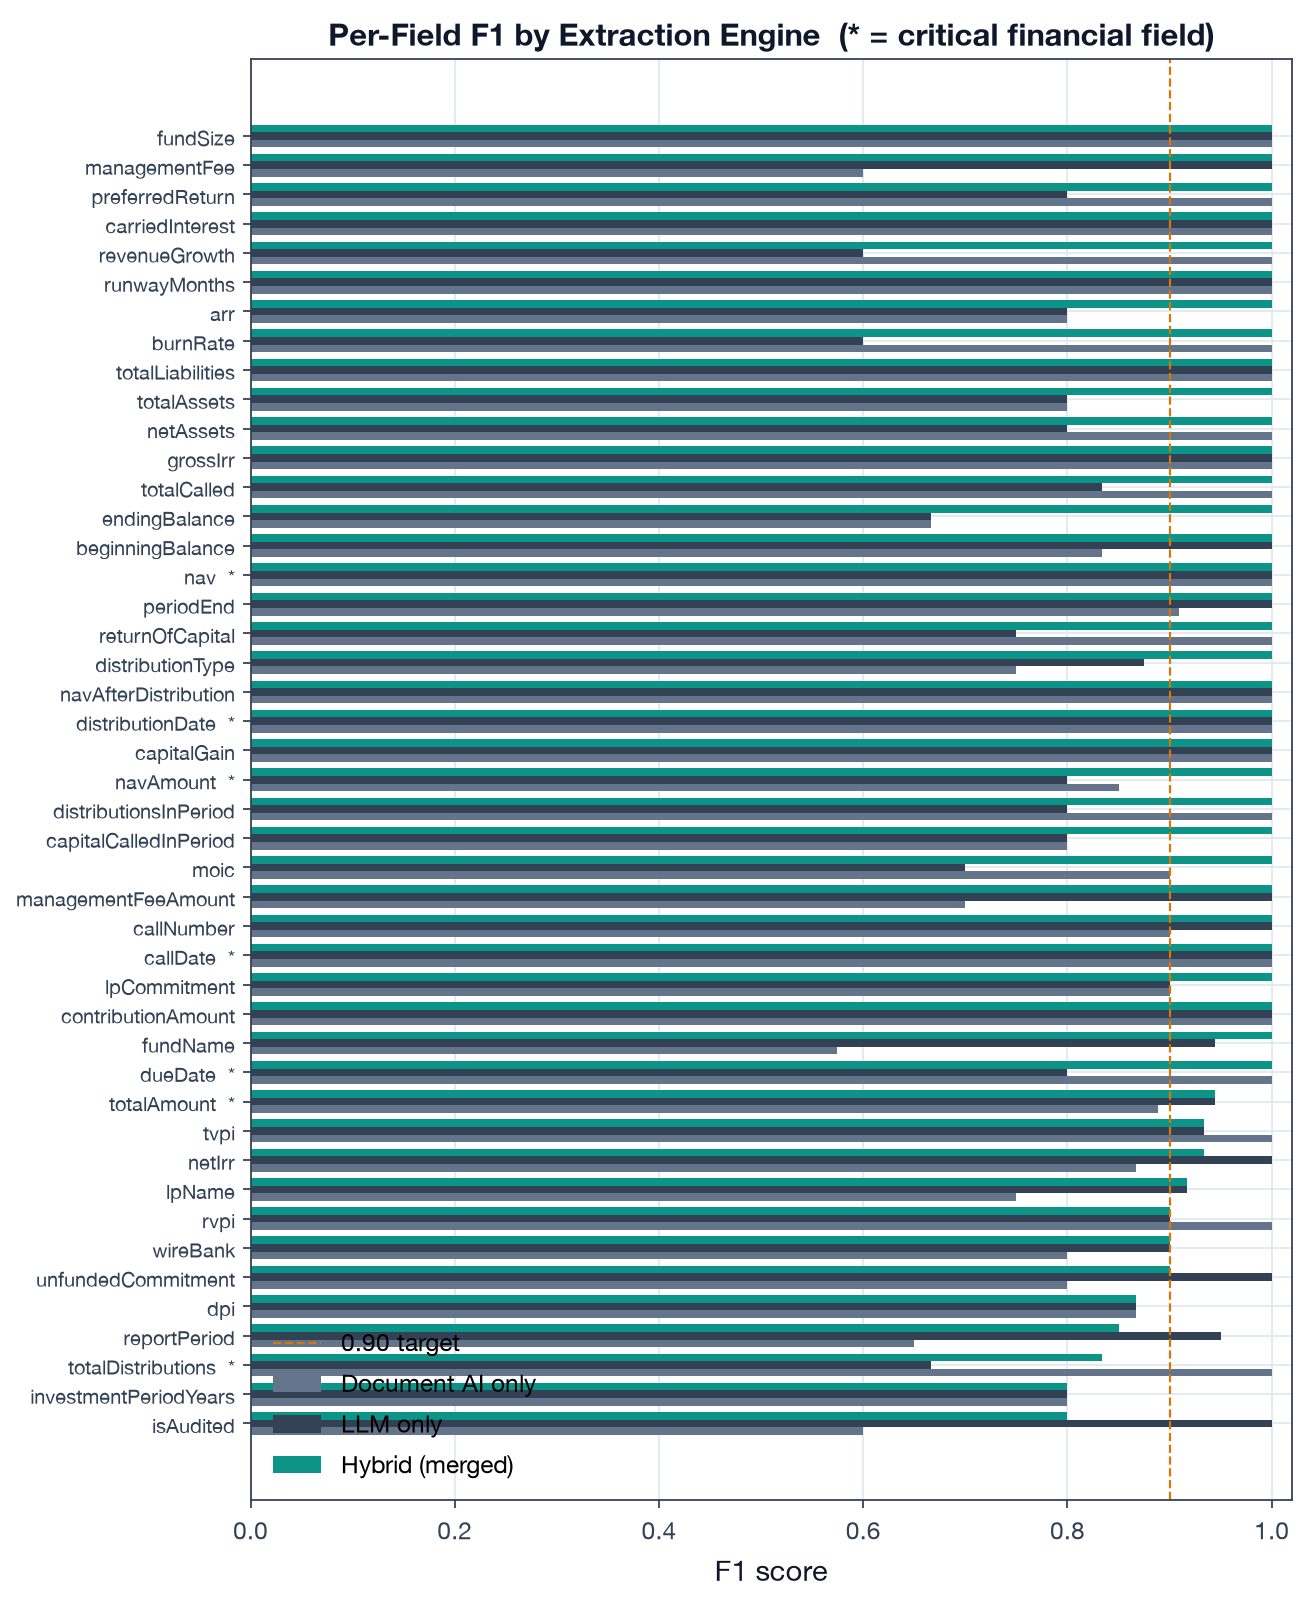

In [4]:
display(Image(str(ROOT/'deliverable-1-extraction-accuracy'/'figures'/'per_field_f1.png')))

## 3. Document-type classification

accuracy 0.889 macro-F1 0.889


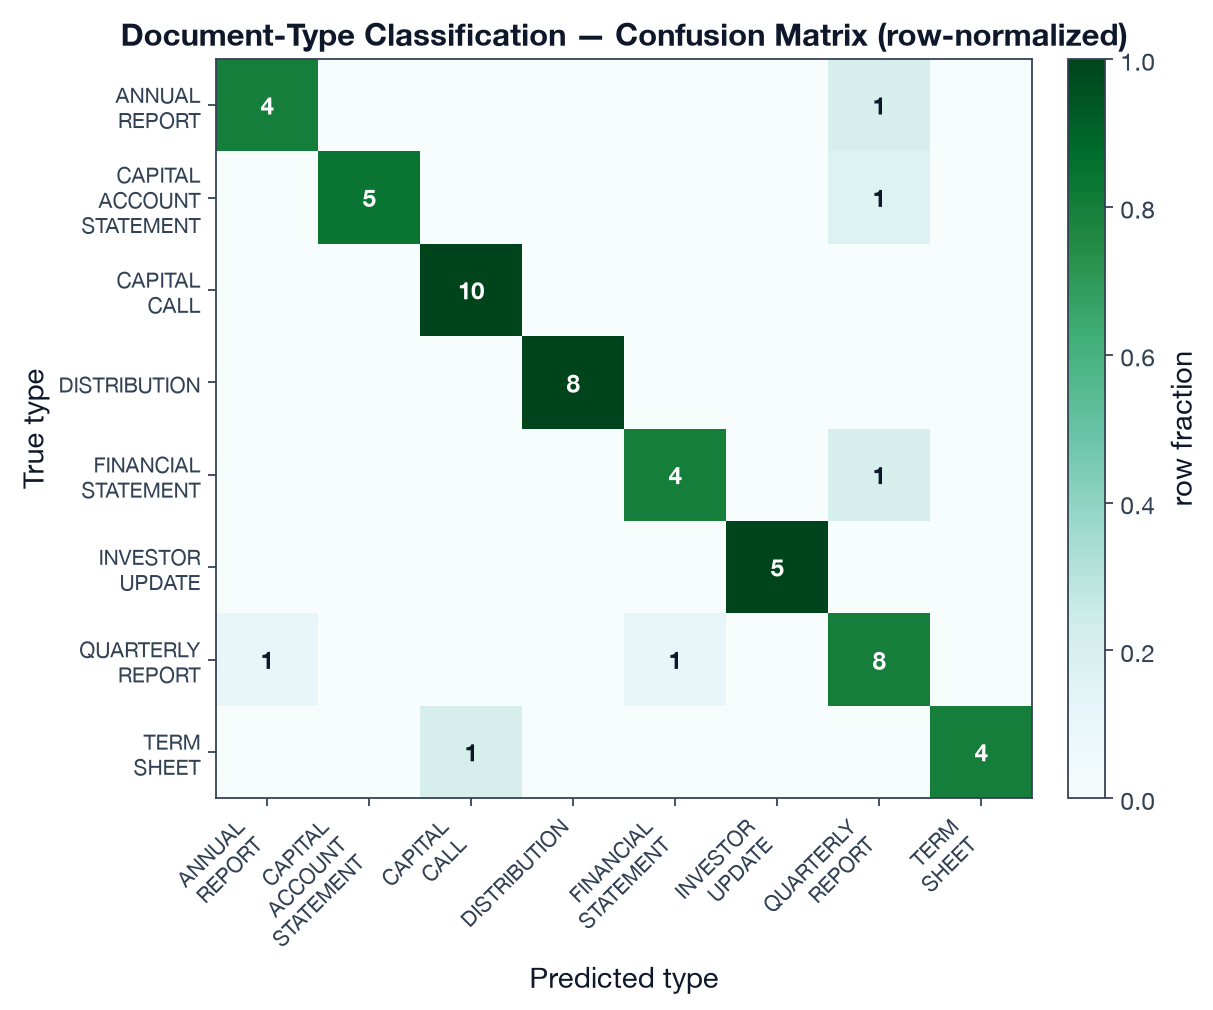

In [5]:
cl = res['classification']
print('accuracy', round(cl['accuracy'],3), 'macro-F1', round(cl['macro_f1'],3))
display(Image(str(ROOT/'deliverable-1-extraction-accuracy'/'figures'/'confusion_matrix.png')))

## 4. F1 by document type

,macro_f1,critical_f1,n
QUARTERLY_REPORT,0.940,1.000,10.000
CAPITAL_CALL,0.955,0.967,10.000
FINANCIAL_STATEMENT,0.967,NaN,5.000
TERM_SHEET,0.967,NaN,5.000
INVESTOR_UPDATE,0.971,1.000,5.000
ANNUAL_REPORT,0.978,1.000,5.000
CAPITAL_ACCOUNT_STATEMENT,0.979,0.917,6.000
DISTRIBUTION,1.000,1.000,8.000


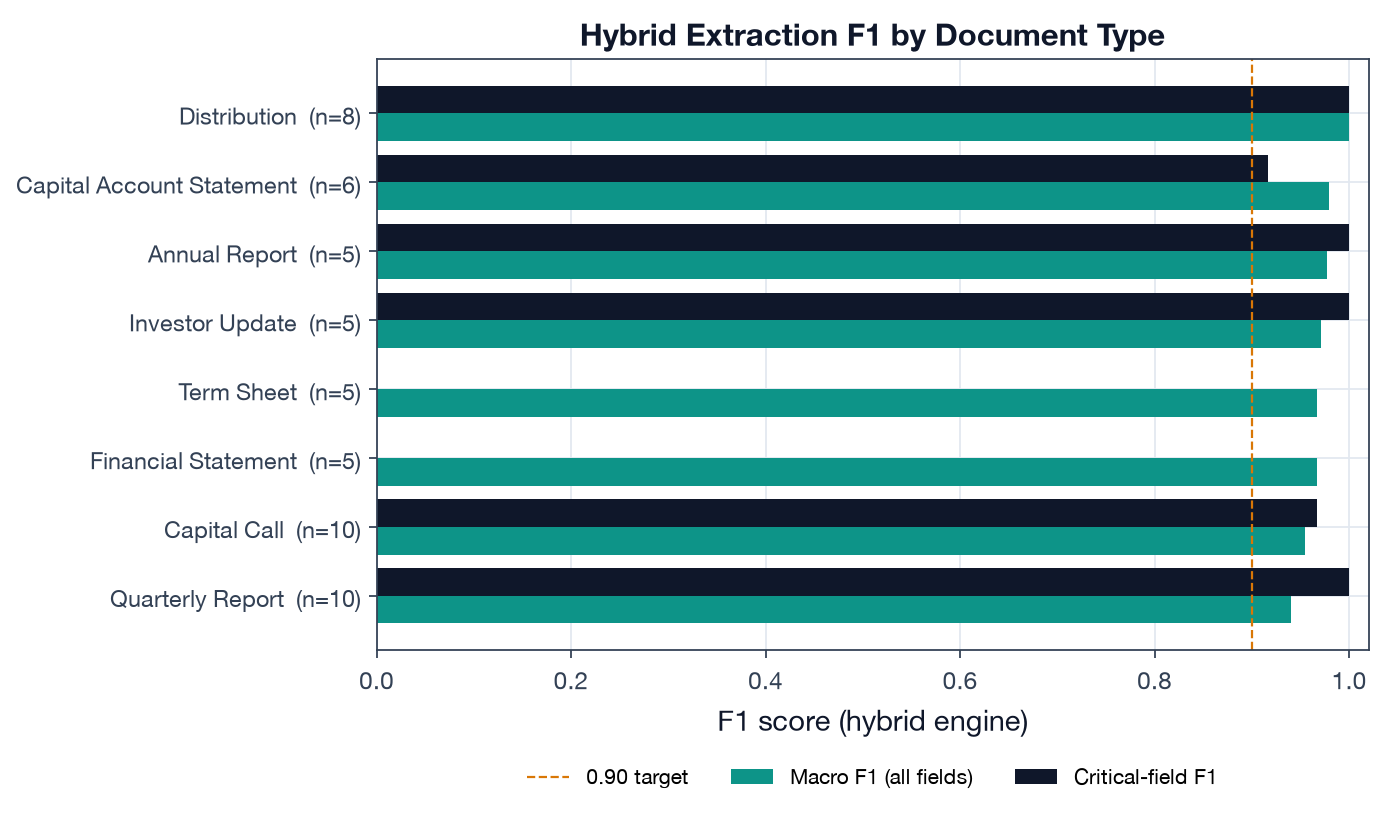

In [6]:
bt = pd.DataFrame(res['by_document_type']).T.sort_values('macro_f1')
display(bt)
display(Image(str(ROOT/'deliverable-1-extraction-accuracy'/'figures'/'f1_by_document_type.png')))

## 5. Live demo — score one document with the real matcher
Showing the numeric-aware containment match on a single capital-call field.

In [7]:
from onelp_eval import extraction_eval as ee
truth = ee.load_jsonl(ROOT/'data'/'extraction'/'ground_truth.jsonl')[0]
pred  = ee.load_jsonl(ROOT/'data'/'extraction'/'predictions_hybrid.jsonl')[0]
for f in ['fundName','totalAmount','dueDate']:
    print(f'{f:14} truth={truth[f]!r:>28}  pred={pred[f]!r:>22}  match={ee.field_match(pred[f], truth[f])}')

fundName       truth='CVC Capital Partners Fund VIII'  pred='CVC Capital Partners Fund VIII'  match=True
totalAmount    truth=                  27000000.0  pred=             2700000.0  match=False
dueDate        truth=                '2024-03-15'  pred=          '2024-03-15'  match=True


### Takeaway
The hybrid architecture is justified by the data: the two single engines fail in opposite directions, and merging them recovers the best of both.